# RLSSM Advanced Tutorial: Build a Custom Model with `ssms.rl`

The [basic RLSSM tutorial](rlssm_basic.ipynb) used the ready-made
`2AB_RW_Angle` preset. A preset is convenient because it already bundles the task,
learning rule, and decision model. Real experiments often need more structure. Here
we build those pieces ourselves for a **three-condition bandit**:

- **AB:** reward probabilities 90% versus 10% (easy),
- **CD:** 75% versus 25% (medium), and
- **EF:** 60% versus 40% (hard).

Each condition is a blocked two-option problem. The learner therefore needs a
separate pair of Q-values for each block, while the same participant-level learning
and decision parameters govern all three blocks.

The customization happens entirely in `ssms.rl`: we write a task environment, a
JAX-compatible learning process, and a `ModelConfig`. After that, the workflow is the
same as before:

```python
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)
model = hssm.RLSSM(data=data, model_config=model_config, ...)
```

We then check group and participant recovery and run condition-stratified posterior
predictive checks.

> **Where this sits in the suite:** start with
> [RLSSM basics](rlssm_basic.ipynb) if the bridge or hierarchical fit is new to you.
> Next, see [one learner driving multiple SSM parameters](rlssm_restless_learner.ipynb)
> or [HSSM-native custom model registration](rlssm_hssm_custom_models.ipynb).

## 1. The three custom pieces

An RLSSM simulation is a repeated loop: prepare the trial, compute decision
parameters from the learner's current state, simulate the choice and RT, deliver the
outcome, and update the learner. `ssms.rl` separates that loop into three objects so
each responsibility is explicit.

### 1.1 Task environment: what happens around a decision?

A task class follows the `TaskEnvironment` protocol. For a discrete-choice task it
also supplies `n_choices` and `response_labels`, satisfying the more specific
`DiscreteChoiceEnvironment` protocol. Two methods divide the trial into before and
after the decision:

- `get_trial_context(trial_idx)` runs **before** the SSM decision. It returns anything
  already known for that trial. Our task returns the current `condition_id`.
- `sample_context(context, trial_idx)` runs **after** the decision. Its `context`
  argument now contains `context["choice"]`, the zero-based option selected by the
  SSM. Our task uses that choice to sample binary `feedback` from the appropriate
  reward probability.

The environment exposes both fields through `context_fields`, making the data
contract visible to the simulator and later to HSSM.

### 1.2 Learning process: why six Q-values?

The basic two-armed preset had one Q-vector with shape `(2,)`. Here AB, CD, and EF
are different problems: experience in AB must not overwrite beliefs about CD or EF.
We therefore store a `(3, 2)` array — three conditions by two options — and use
`condition_id` to select the row updated on each trial.

The Rescorla–Wagner update is unchanged:

$$
Q_{k,c} \leftarrow Q_{k,c} + \alpha(r-Q_{k,c}),
$$

where $k$ is the condition and $c$ is the chosen option. Before the update, the
current value difference becomes the angle model's drift:

$$
v = (Q_{k,1}-Q_{k,0})\,\text{scaler}.
$$

### 1.3 Model configuration: assemble the contract

`ModelConfig` connects the custom environment and learner to a registered decision
process (`"angle"`). Its validation checks that the learner-computed SSM parameters
and the fixed parameters supplied in `theta` cover the decision model exactly, that
all free parameters have bounds/defaults, and that task response labels match the
decision model.

Compared with the preset tutorial, we now **own** the environment class, learning
class, and `ModelConfig` assembly. We still **inherit** the HSSM bridge, hierarchical
parameter machinery, NumPyro sampling pattern, recovery logic, and `mode="ppc"`
simulation workflow.

## 2. Setup

In [1]:
import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hssm
import ssms.rl as rl

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

# HSSM and the JAX learner must agree on numerical precision.
hssm.set_floatX("float32", update_jax=True)
RANDOM_SEED = 20260505

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


### 2.1 Simulation and sampling scale

The same notebook supports a quick documentation run and a richer committed run.
Set the environment variable `FULL_RUN=1` for the latter. Because each participant
completes all three blocks, 50 trials per condition means 150 total trials per
participant.

In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

N_PARTICIPANTS = 15 if FULL_RUN else 5
N_TRIALS_PER_CONDITION = 50 if FULL_RUN else 23
N_CONDITIONS = 3
N_TRIALS = N_TRIALS_PER_CONDITION * N_CONDITIONS
N_CHAINS = 2
N_TUNE = 1000 if FULL_RUN else 300
N_DRAWS = 500 if FULL_RUN else 300
N_PPC_DRAWS = 20 if FULL_RUN else 8

CONDITIONS = [
    {"condition_id": 0, "label": "AB", "reward_probs": [0.90, 0.10]},
    {"condition_id": 1, "label": "CD", "reward_probs": [0.75, 0.25]},
    {"condition_id": 2, "label": "EF", "reward_probs": [0.60, 0.40]},
]
CONDITION_LABELS = {c["condition_id"]: c["label"] for c in CONDITIONS}

print(
    f"scale: {N_PARTICIPANTS} participants x {N_TRIALS} trials "
    f"({N_TRIALS_PER_CONDITION} per condition)"
)

scale: 5 participants x 69 trials (23 per condition)


## 3. Write the custom task environment

`ThreeConditionBandit` creates the blocked schedule by repeating each condition
`N_TRIALS_PER_CONDITION` times. On every trial:

1. `get_trial_context` publishes the block's numeric `condition_id` before the
   decision;
2. the simulator maps the angle model's response label (`-1` or `1`) to zero-based
   `choice` (`0` or `1`); and
3. `sample_context` reads that choice and samples feedback from the selected option's
   Bernoulli reward probability.

`reset` receives a fresh random-number generator for each participant. Keeping the
RNG inside the environment makes simulations reproducible without sharing reward
streams across participants.

In [3]:
class ThreeConditionBandit:
    "Blocked three-condition Bernoulli bandit (AB, CD, EF)."

    def __init__(self, conditions, trials_per_condition):
        self._conditions = list(conditions)
        self._trials_per = int(trials_per_condition)
        self._schedule = [
            condition
            for condition in self._conditions
            for _ in range(self._trials_per)
        ]
        self._rng = None

    @property
    def context_fields(self):
        # Both columns become part of the simulator/HSSM trial-data contract.
        return ["condition_id", "feedback"]

    @property
    def n_choices(self):
        return 2

    @property
    def response_labels(self):
        # The angle SSM labels its two boundaries -1 and 1.
        return [-1, 1]

    def reset(self, rng=None):
        "Start a participant with the simulator-provided RNG."
        self._rng = rng

    def get_trial_context(self, trial_idx):
        "Publish the condition before the decision is simulated."
        condition = self._schedule[trial_idx]
        return {"condition_id": float(condition["condition_id"])}

    def sample_context(self, context, trial_idx):
        "Sample feedback after reading the simulator's zero-based choice."
        condition = self._schedule[trial_idx]
        choice = int(context["choice"])
        reward_probability = condition["reward_probs"][choice]
        feedback = float(self._rng.random() < reward_probability)
        return {"feedback": feedback}

## 4. Write the condition-aware JAX learning process

The learner declares two kinds of parameters:

- `free_params = ["rl_alpha", "scaler"]` are participant parameters supplied during
  simulation and estimated by HSSM;
- `computed_params = ["v"]` says the learner calculates the trial-wise drift rather
  than asking the user to provide a fixed `v`.

We implement matching Python/NumPy and JAX paths. The Python path drives ordinary
simulation. HSSM differentiates through the JAX path during NUTS sampling, so
`available_backends` must include `"jax"` and `supports_gradient` must truthfully be
`True`.

There is one small but load-bearing detail below: trial data can store
`condition_id` as a floating-point column, but JAX array indexing requires an integer.
Both `compute_jax` and `update_jax` explicitly cast it with `jnp.int32(...)` before
indexing the `(3, 2)` Q-value array.

In [4]:
class ConditionAwareRWLearner:
    "Rescorla–Wagner learner with a separate Q-value pair per condition."

    def __init__(self, n_conditions=3, initial_q=0.5):
        self._n_conditions = n_conditions
        self._initial_q = initial_q

    @property
    def computed_params(self):
        return ["v"]

    @property
    def free_params(self):
        return ["rl_alpha", "scaler"]

    @property
    def param_bounds(self):
        return {"rl_alpha": (0.0, 1.0), "scaler": (0.001, 10.0)}

    @property
    def default_params(self):
        return {"rl_alpha": 0.2, "scaler": 2.0}

    @property
    def available_backends(self):
        return ("python", "jax")

    @property
    def supports_gradient(self):
        return True

    @property
    def required_context_fields(self):
        # choice is supplied by the simulator; the other fields come from the task.
        return ["condition_id", "choice", "feedback"]

    def init_state(self):
        q_values = np.full(
            (self._n_conditions, 2), self._initial_q, dtype=np.float64
        )
        return {"q_values": q_values}

    def init_jax_state(self):
        import jax.numpy as jnp

        return {
            "q_values": jnp.full((self._n_conditions, 2), self._initial_q)
        }

    def compute_python(self, state, params, context):
        condition_id = int(context["condition_id"])
        q_values = state["q_values"][condition_id]
        drift = (q_values[1] - q_values[0]) * params["scaler"]
        return {"v": float(drift)}

    def compute_jax(self, state, params, context):
        import jax.numpy as jnp

        condition_id = jnp.int32(context["condition_id"])
        q_values = state["q_values"][condition_id]
        return {"v": (q_values[1] - q_values[0]) * params["scaler"]}

    def update_python(self, state, params, context):
        condition_id = int(context["condition_id"])
        choice = int(context["choice"])
        feedback = float(context["feedback"])
        q_values = state["q_values"].copy()
        prediction_error = feedback - q_values[condition_id, choice]
        q_values[condition_id, choice] += params["rl_alpha"] * prediction_error
        return {"q_values": q_values}

    def update_jax(self, state, params, context):
        import jax.numpy as jnp

        condition_id = jnp.int32(context["condition_id"])
        choice = context["choice"]
        feedback = context["feedback"]
        q_values = state["q_values"]
        prediction_error = feedback - q_values[condition_id, choice]
        delta = params["rl_alpha"] * prediction_error
        return {"q_values": q_values.at[condition_id, choice].add(delta)}

## 5. Assemble the model, simulate, and validate

`ModelConfig` is the structural specification — it contains classes and metadata,
not participant parameter values. `validate()` checks the cross-component contract.
`assemble(backend="jax")` resolves the backend and the handshake between the learner
and angle SSM; `gradient == "available"` confirms that HSSM can use a gradient-based
sampler.

In [5]:
ssms_config = rl.ModelConfig(
    model_name="3Condition_RW_Angle",
    description="Three blocked bandit conditions with condition-specific RW learning.",
    decision_process="angle",
    learning_process=ConditionAwareRWLearner(n_conditions=N_CONDITIONS),
    task_environment=ThreeConditionBandit(CONDITIONS, N_TRIALS_PER_CONDITION),
    context_fields=["condition_id", "feedback"],
)

ssms_config.validate()
assembled = ssms_config.assemble(backend="jax")
print("free parameters:", ssms_config.list_params)
print("learner-computed SSM parameters:", assembled.computed_params)
print("gradient support:", assembled.gradient)
assert assembled.gradient == "available"
assert set(assembled.computed_params) == {"v"}

free parameters: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
learner-computed SSM parameters: ['v']
gradient support: available


Because this is a recovery tutorial, we simulate from known group means and genuine
participant differences. The values below come from the validated three-condition
angle-bandit recovery example. Parameter-specific `SDS` matter: a bounded quantity
such as `z` should vary much less than the drift `scaler`, and the individual-level
recovery plot needs real variation to recover.

The helper samples one value per participant, clips it to the supported range, and
returns both array-valued `theta` for `Simulator` and a table of truths for later.

In [6]:
GROUP_THETA = {
    "rl_alpha": 0.12,  # learning rate
    "scaler": 2.20,    # Q-value difference -> drift gain
    "a": 1.45,         # boundary separation
    "z": 0.50,         # starting-point bias (0.5 = unbiased)
    "t": 0.20,         # non-decision time (seconds)
    "theta": 0.20,     # angle/collapse parameter
}
SDS = {
    "rl_alpha": 0.02,
    "scaler": 0.20,
    "a": 0.10,
    "z": 0.02,
    "t": 0.03,
    "theta": 0.04,
}
BOUNDS = {
    "rl_alpha": (0.01, 1.0),
    "scaler": (0.1, 5.0),
    "a": (0.3, 2.5),
    "z": (0.1, 0.9),
    "t": (0.05, 1.0),
    "theta": (0.0, 1.2),
}
LIST_PARAMS = list(GROUP_THETA)


def make_participant_theta(group_theta, sds, bounds, n_participants, rng):
    "Draw bounded participant parameters around known group means."
    theta = {
        name: np.clip(
            rng.normal(group_theta[name], sds[name], n_participants), *bounds[name]
        )
        for name in group_theta
    }
    true = pd.DataFrame(theta)
    true.index.name = "participant_id"
    return theta, true


rng = np.random.default_rng(RANDOM_SEED)
theta_arrays, true_params = make_participant_theta(
    GROUP_THETA, SDS, BOUNDS, N_PARTICIPANTS, rng
)
true_params.round(3)

,rl_alpha,scaler,a,z,t,theta
participant_id,,,,,,
0,0.115,2.535,1.571,0.515,0.205,0.267
1,0.115,2.075,1.564,0.472,0.192,0.231
2,0.128,2.136,1.575,0.469,0.181,0.215
3,0.084,1.887,1.580,0.493,0.173,0.157
4,0.105,2.297,1.299,0.484,0.245,0.228


One simulator call now runs the complete trial loop for every participant and block.
Afterward, `validate_data(...).raise_for_errors()` checks the **real dataframe**:
required columns, balanced and ordered participant panels, valid responses, and
usable context fields. Running this before HSSM gives a direct error at the data
boundary instead of a cryptic failure inside the likelihood.

In [7]:
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays,
    n_trials=N_TRIALS,
    n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)
ssms_config.validate_data(data).raise_for_errors()

# Add labels and a within-condition trial counter for readable plots only.
data["condition_label"] = data["condition_id"].astype(int).map(CONDITION_LABELS)
data["condition_trial"] = data.groupby(
    ["participant_id", "condition_id"], observed=True
).cumcount()

print("rows:", len(data), "| columns:", list(data.columns))
data.head()

rows: 345 | columns: ['participant_id', 'trial_id', 'rt', 'response', 'condition_id', 'feedback', 'condition_label', 'condition_trial']


,participant_id,trial_id,rt,response,condition_id,feedback,condition_label,condition_trial
0,0,0,1.926506,-1,0.0,1.0,AB,0
1,0,1,2.583203,-1,0.0,1.0,AB,1
2,0,2,2.617862,-1,0.0,1.0,AB,2
3,0,3,0.892677,1,0.0,0.0,AB,3
4,0,4,1.843108,-1,0.0,1.0,AB,4


Before fitting, check that the manipulation is visible. Option `0` maps to response
`-1` and is the high-reward option in all blocks. AB should show the clearest shift
toward that option, CD a smaller shift, and EF the weakest because its rewards are
closest to chance. The curves need not be perfectly monotonic — feedback is noisy —
but their ordering should reflect the three reward gaps.

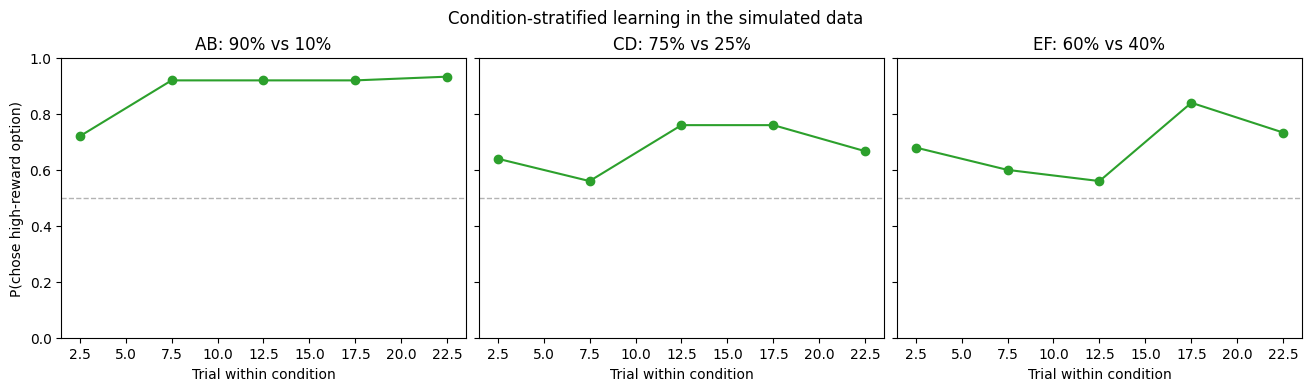

In [8]:
BIN_SIZE = 5
learning = data[data["rt"] > 0].copy()
learning["chose_high"] = (learning["response"] == -1).astype(float)
learning["trial_bin"] = (
    learning["condition_trial"] // BIN_SIZE
) * BIN_SIZE

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, condition in zip(axes, CONDITIONS):
    label = condition["label"]
    curve = (
        learning[learning["condition_label"] == label]
        .groupby("trial_bin", observed=True)["chose_high"]
        .mean()
    )
    ax.plot(curve.index + BIN_SIZE / 2, curve.values, "o-", color="tab:green")
    ax.axhline(0.5, color="0.7", ls="--", lw=1)
    ax.set_title(
        f"{label}: {condition['reward_probs'][0]:.0%} vs "
        f"{condition['reward_probs'][1]:.0%}"
    )
    ax.set_xlabel("Trial within condition")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("P(chose high-reward option)")
fig.suptitle("Condition-stratified learning in the simulated data")
plt.show()

## 6. Bridge the custom model into HSSM

The bridge call is exactly the same as for a preset. It inspects the assembled
`ssms.rl` model and creates HSSM metadata for the free parameters, bounds, JAX
learning function, and trial-level context.

Notice that `condition_id` appears in `extra_fields`. That is the practical payoff
of declaring the custom environment's context: HSSM now passes the block identifier
into the likelihood on every trial. Drift `v` remains learner-computed and therefore
must not appear among the sampled parameters.

In [9]:
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)

print("list_params (free):", model_config.list_params)
print("extra_fields:", model_config.extra_fields)
print("computed by learner:", set(model_config.ssm_logp_func.computed))
assert "condition_id" in model_config.extra_fields
assert "v" in model_config.ssm_logp_func.computed
assert "v" not in model_config.list_params

list_params (free): ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
extra_fields: ['condition_id', 'feedback']
computed by learner: {'v'}


## 7. Specify hierarchical priors and build the model

As in the basic tutorial, every parameter has a group intercept and a participant
deviation:

```
rl_alpha ~ 1 + (1 | participant_id)
```

The `TruncatedNormal` intercept prior respects each parameter's valid bounds. The
participant effect has fixed mean **0**, leaving the intercept as the sole owner of
the population location, while a `HalfNormal` prior learns how much participants
vary. The helper keeps this repeated specification readable.

In [10]:
PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal",
    "mu": 0,
    "sigma": {"name": "HalfNormal", "sigma": 0.5},
}


def hierarchical_param(name, lower, upper, mu, sigma):
    "Group intercept plus mean-zero participant deviations."
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior(
                "TruncatedNormal", lower=lower, upper=upper, mu=mu, sigma=sigma
            ),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )

The model constructor receives the same trial data and bridged config. Two choices
keep this tutorial focused: `p_outlier=0` and `lapse=None` disable mixture components.

> **Important RLSSM sampling setting:** use `process_initvals=False`. Processed
> initial values can place this model in a region where the float32 NUTS step size
> collapses and the posterior stays near the prior despite the run finishing.
> Starting from the prior avoids that failure mode.

In [11]:
model = hssm.RLSSM(
    data=data,
    model_config=model_config,
    p_outlier=0,
    lapse=None,
    process_initvals=False,
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, 0.15, 0.15),
        hierarchical_param("scaler", 0.1, 5.0, 2.2, 0.8),
        hierarchical_param("a", 0.3, 2.5, 1.4, 0.3),
        hierarchical_param("z", 0.1, 0.9, 0.5, 0.15),
        hierarchical_param("t", 0.05, 1.0, 0.2, 0.1),
        hierarchical_param("theta", 0.0, 1.2, 0.2, 0.15),
    ],
)

print("participants:", model.n_participants, "| trials/participant:", model.n_trials)
print("free parameters:", list(model.params))
assert "v" not in model.params

You supplied a model '3Condition_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


participants: 5 | trials/participant: 69
free parameters: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


HSSM builds the formula model through Bambi and the probability model through PyMC.
Printing the model is a useful structural check: every free parameter should have an
intercept and a participant term, while `v` should be absent because the learner
computes it trial by trial.

In [12]:
print(model.model)

       Formula: c(rt, response) ~ 1 + (1|participant_id)
                scaler ~ 1 + (1|participant_id)
                a ~ 1 + (1|participant_id)
                z ~ 1 + (1|participant_id)
                t ~ 1 + (1|participant_id)
                theta ~ 1 + (1|participant_id)
        Family: SSM Family
          Link: rl_alpha = identity
                scaler = identity
                a = identity
                z = identity
                t = identity
                theta = identity
  Observations: 345
        Priors: 
    target = rl_alpha
        Common-level effects
            Intercept ~ TruncatedNormal(lower: 0.009999999776482582, upper: 1.0, mu: 0.15000000596046448,
                sigma: 0.15000000596046448)
        
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.5))
    target = scaler
        Common-level effects
            scaler_Intercept ~ TruncatedNormal(lower: 0.10000000149011612, upper: 5.0, mu:


## 8. Sample the posterior

NumPyro's NUTS sampler differentiates through the custom JAX learner. The doc-scale
run is intentionally short; `FULL_RUN=1` uses the 1,000 warmup and 500 retained draws
used for the committed recovery output.

In [13]:
idata = model.sample(
    sampler="numpyro",
    draws=N_DRAWS,
    tune=N_TUNE,
    chains=N_CHAINS,
    cores=N_CHAINS,
    target_accept=0.9,
    random_seed=RANDOM_SEED,
)
idata

Using default initvals. 



  0%|          | 0/600 [00:00<?, ?it/s]

warmup:   0%|          | 1/600 [00:01<11:06,  1.11s/it, 1 steps of size 1.95e+00. acc. prob=0.00]

warmup:   1%|          | 7/600 [00:01<01:54,  5.18it/s, 807 steps of size 1.43e-03. acc. prob=0.49]

warmup:   1%|▏         | 8/600 [00:01<02:02,  4.82it/s, 483 steps of size 1.78e-03. acc. prob=0.56]

...

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 1/600 [00:00<01:23,  7.21it/s]

 47%|████▋     | 280/600 [00:00<00:00, 1417.51it/s]

100%|██████████| 600/600 [00:00<00:00, 1797.23it/s]

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

## 9. Parameter recovery

The model uses one set of participant parameters across AB, CD, and EF. The
**behavior** is condition-stratified because reward histories create different
Q-values; the six recovered parameters are not condition-indexed. We therefore use
the same two recovery views as in the basic tutorial:

1. group intercepts versus the known group means; and
2. each participant's intercept-plus-deviation estimate versus their true value.

All six parameters use identity links here, so no inverse transformation is needed.

In [14]:
def group_recovery(idata, true_group):
    "Plot group intercept posteriors against known population means."
    names = [f"{name}_Intercept" for name in LIST_PARAMS]
    summary = az.summary(idata, var_names=names, kind="stats")
    summary.index = LIST_PARAMS
    summary["true"] = [true_group[name] for name in LIST_PARAMS]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(LIST_PARAMS))
    ax.errorbar(
        summary["mean"],
        y,
        xerr=[
            summary["mean"] - summary["hdi_3%"],
            summary["hdi_97%"] - summary["mean"],
        ],
        fmt="o",
        capsize=4,
        label="posterior (94% HDI)",
    )
    ax.scatter(
        summary["true"], y, color="crimson", marker="D", zorder=5,
        label="true group mean"
    )
    ax.set_yticks(y)
    ax.set_yticklabels(LIST_PARAMS)
    ax.invert_yaxis()
    ax.set_title("Group-level recovery")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return summary


def participant_recovery(idata, true_values):
    "Plot true versus recovered participant values for all six parameters."
    post = idata.posterior
    fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    correlations = {}

    for ax, name in zip(axes.ravel(), LIST_PARAMS):
        effect = post[f"{name}_1|participant_id"]
        participant_dim = [
            dim for dim in effect.dims if dim not in ("chain", "draw")
        ][0]
        draws = post[f"{name}_Intercept"] + effect
        recovered = draws.mean(("chain", "draw")).values
        lower = draws.quantile(0.03, ("chain", "draw")).values
        upper = draws.quantile(0.97, ("chain", "draw")).values
        participant_ids = [int(value) for value in effect[participant_dim].values]
        truth = true_values.loc[participant_ids, name].values
        correlation = float(np.corrcoef(truth, recovered)[0, 1])
        correlations[name] = correlation

        ax.errorbar(
            truth,
            recovered,
            yerr=[recovered - lower, upper - recovered],
            fmt="o",
            ecolor="0.7",
            capsize=3,
        )
        limits = [
            min(truth.min(), recovered.min()) - 0.03,
            max(truth.max(), recovered.max()) + 0.03,
        ]
        ax.plot(limits, limits, "k--", lw=1)
        ax.set_title(f"{name} (r = {correlation:.2f})")
        ax.set_xlabel("true")
        ax.set_ylabel("recovered")
        ax.grid(alpha=0.3)

    fig.suptitle("Participant-level recovery (dashed line = perfect)")
    plt.show()
    return pd.Series(correlations, name="correlation")

### 9.1 Group-level recovery

Each blue interval is the posterior 94% HDI for a group intercept; the red diamond
is the value used to simulate the data. A convincing recovery places the diamonds
inside or very near their intervals rather than merely producing an error-free fit.

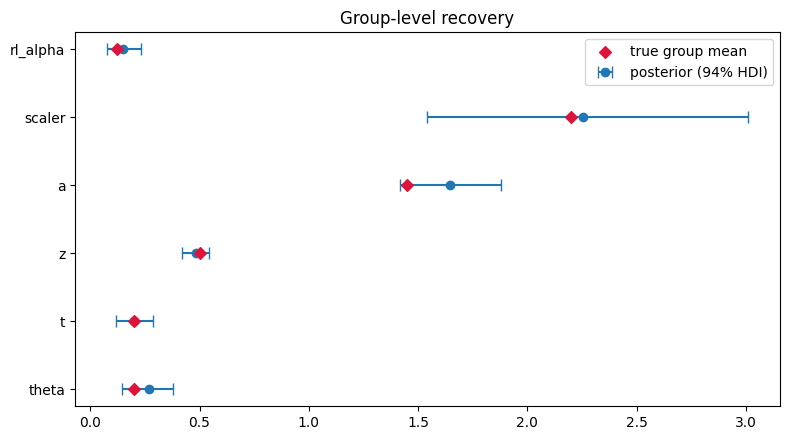

,mean,hdi_3%,hdi_97%,true
rl_alpha,0.151,0.077,0.233,0.12
scaler,2.256,1.541,3.010,2.20
a,1.648,1.419,1.878,1.45
z,0.482,0.420,0.542,0.50
t,0.202,0.119,0.286,0.20
theta,0.270,0.147,0.380,0.20


In [15]:
group_summary = group_recovery(idata, GROUP_THETA)
group_summary[["mean", "hdi_3%", "hdi_97%", "true"]].round(3)

### 9.2 Participant-level recovery

The points reconstruct each participant's parameter as `Intercept + deviation` and
compare it with that participant's simulation truth. The interval bars show
individual uncertainty. Decision parameters are usually recovered more sharply than
the two RL parameters, which must be inferred indirectly through an entire noisy
learning history.

Again, AB/CD/EF do not get separate parameter panels: they are repeated conditions
generated by the same participant, not three different parameter populations.

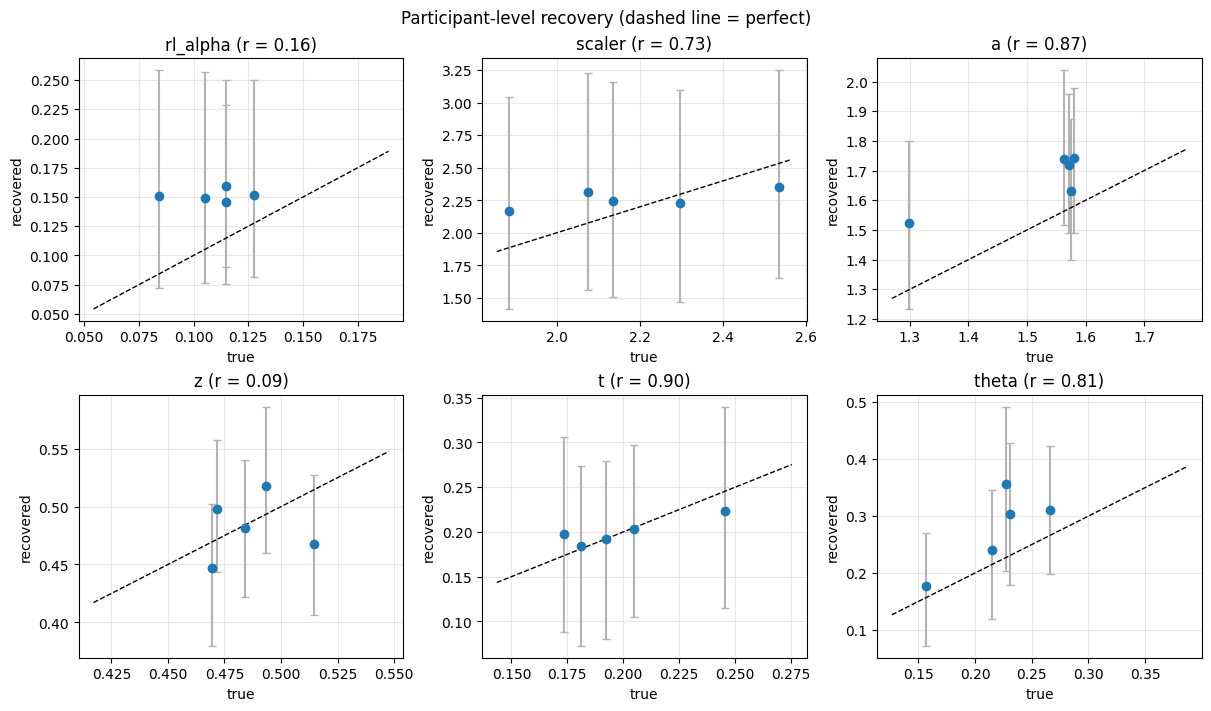

participant correlations:
rl_alpha    0.16
scaler      0.73
a           0.87
z           0.09
t           0.90
theta       0.81
max r-hat: 1.020 | divergences: 102


In [16]:
participant_correlations = participant_recovery(idata, true_params)

max_rhat = max(float(az.rhat(idata)[name].max()) for name in az.rhat(idata).data_vars)
divergences = int(idata.sample_stats["diverging"].sum())
print("participant correlations:")
print(participant_correlations.round(2).to_string())
print(f"max r-hat: {max_rhat:.3f} | divergences: {divergences}")

## 10. Condition-stratified posterior predictive checks

A posterior predictive check (PPC) asks whether fitted parameters can generate the
behavioral patterns present in the observed data. RLSSMs need more care than a model
of independent trials because every choice and reward changes the learner's future
state.

`ssms.rl` provides `mode="ppc"` for this purpose. It replays each participant's
**observed responses and feedback when updating Q-values**, keeping the predicted
learning trajectory conditioned on the history that was actually observed. The
choice and RT emitted by the SSM are newly simulated from a posterior parameter draw.
This tests the decision model along a comparable learning path instead of adding a
second, unrelated reward history.

We sample several complete posterior draws. Each draw contains a coherent set of all
six parameters for every participant; mixing parameter values from different draws
would destroy posterior correlations. The helper reconstructs natural-scale
participant values as `Intercept + deviation`.

In [17]:
def draw_posterior_theta(idata, sample_idx):
    "Return one coherent posterior draw of every participant parameter."
    posterior = idata.posterior.stack(sample=("chain", "draw"))
    theta = {}

    for name in LIST_PARAMS:
        effect = posterior[f"{name}_1|participant_id"]
        participant_dim = [dim for dim in effect.dims if dim != "sample"][0]
        values = (
            posterior[f"{name}_Intercept"] + effect
        ).isel(sample=sample_idx)
        participant_ids = [int(value) for value in effect[participant_dim].values]
        ordered = pd.Series(
            np.asarray(values.values), index=participant_ids
        ).sort_index()
        theta[name] = ordered.reindex(range(N_PARTICIPANTS)).to_numpy()

    return theta


n_posterior_samples = (
    idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
)
ppc_rng = np.random.default_rng(RANDOM_SEED + 1)
sample_ids = ppc_rng.choice(
    n_posterior_samples,
    size=min(N_PPC_DRAWS, n_posterior_samples),
    replace=False,
)

ppc_frames = []
for ppc_draw, sample_idx in enumerate(sample_ids):
    theta_draw = draw_posterior_theta(idata, int(sample_idx))
    simulated = rl.Simulator(ssms_config).simulate(
        theta=theta_draw,
        mode="ppc",
        observed_data=data,
        random_state=RANDOM_SEED + 100 + ppc_draw,
    )
    simulated["ppc_draw"] = ppc_draw
    simulated["condition_label"] = (
        simulated["condition_id"].astype(int).map(CONDITION_LABELS)
    )
    simulated["condition_trial"] = simulated.groupby(
        ["participant_id", "condition_id"], observed=True
    ).cumcount()
    ppc_frames.append(simulated)

ppc_data = pd.concat(ppc_frames, ignore_index=True)
print(
    f"PPC datasets: {len(sample_ids)} | rows per dataset: {len(data)} | "
    f"total rows: {len(ppc_data)}"
)

PPC datasets: 8 | rows per dataset: 345 | total rows: 2760


### 10.1 Learning curves by condition

The observed black line and posterior-predictive blue line should have similar
levels within each condition. The blue ribbon is the 94% interval across replicated
datasets. More importantly, the fitted model should reproduce the task's ordering:
strongest preference for the high-reward option in AB, weaker preference in CD, and
the most uncertainty in EF.

These are behavioral curves, not separate parameter estimates. The same posterior
`rl_alpha` and `scaler` generate all three panels; the reward schedules and separate
Q-value rows produce the differences.

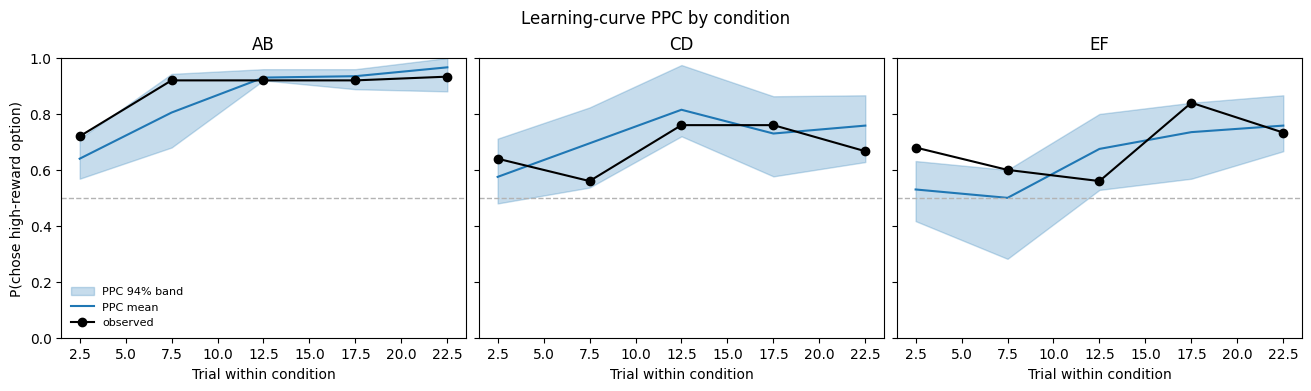

In [18]:
def binned_learning_curve(dataframe, include_draw=False, bin_size=5):
    "Summarize high-reward choices by condition and within-condition trial bin."
    valid = dataframe[
        np.isfinite(dataframe["rt"])
        & (dataframe["rt"] > 0)
        & (dataframe["response"] > -900)
    ].copy()
    valid["chose_high"] = (valid["response"] == -1).astype(float)
    valid["trial_bin"] = (
        valid["condition_trial"] // bin_size
    ) * bin_size
    group_columns = ["condition_label", "trial_bin"]
    if include_draw:
        group_columns.insert(0, "ppc_draw")
    return (
        valid.groupby(group_columns, observed=True)["chose_high"]
        .mean()
        .reset_index()
    )


observed_curves = binned_learning_curve(data)
predicted_curves = binned_learning_curve(ppc_data, include_draw=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, condition in zip(axes, CONDITIONS):
    label = condition["label"]
    observed = observed_curves[
        observed_curves["condition_label"] == label
    ].set_index("trial_bin")["chose_high"]
    predicted = (
        predicted_curves[predicted_curves["condition_label"] == label]
        .pivot(index="trial_bin", columns="ppc_draw", values="chose_high")
        .sort_index()
    )
    centers = predicted.index + BIN_SIZE / 2

    ax.fill_between(
        centers,
        predicted.quantile(0.03, axis=1),
        predicted.quantile(0.97, axis=1),
        color="tab:blue",
        alpha=0.25,
        label="PPC 94% band",
    )
    ax.plot(
        centers, predicted.mean(axis=1), color="tab:blue", lw=1.5,
        label="PPC mean"
    )
    ax.plot(
        observed.index + BIN_SIZE / 2, observed.values, "o-", color="black",
        label="observed"
    )
    ax.axhline(0.5, color="0.7", ls="--", lw=1)
    ax.set_title(label)
    ax.set_xlabel("Trial within condition")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("P(chose high-reward option)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Learning-curve PPC by condition")
plt.show()

### 10.2 Signed response times by condition

Signed RT places both outcomes on one axis: negative values represent the
high-reward response (`-1`), and positive values represent the lower-reward response
(`1`). Each panel therefore checks the response proportions and RT distribution
together. The observed and posterior-predictive outlines need not coincide exactly,
but major differences in side, spread, or tail length would reveal model misfit.

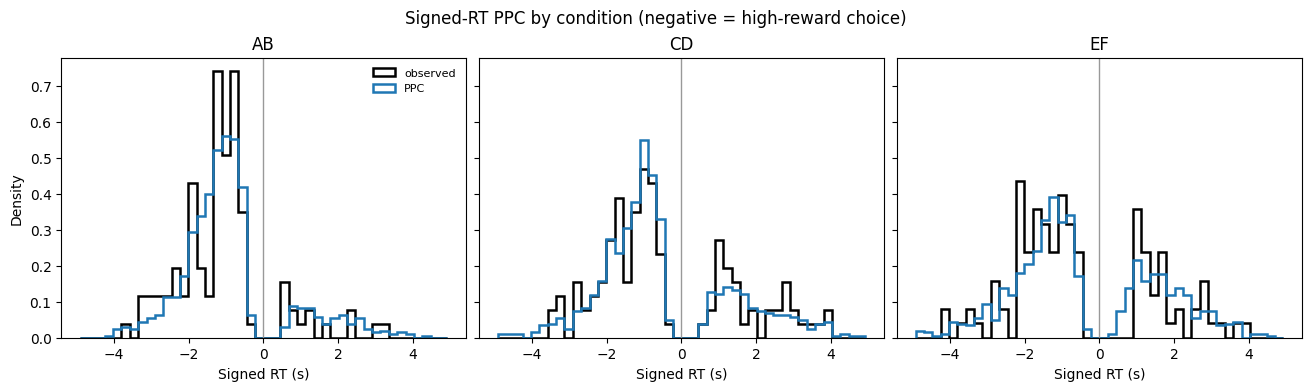

In [19]:
def signed_rt(dataframe):
    "Return finite RTs signed by response (- = high reward, + = low reward)."
    valid = dataframe[
        np.isfinite(dataframe["rt"])
        & (dataframe["rt"] > 0)
        & (dataframe["response"] > -900)
    ]
    return np.where(
        valid["response"].astype(int) == -1,
        -valid["rt"].astype(float),
        valid["rt"].astype(float),
    )


all_signed_rt = np.concatenate([signed_rt(data), signed_rt(ppc_data)])
rt_limit = np.quantile(np.abs(all_signed_rt), 0.995)
bins = np.linspace(-rt_limit, rt_limit, 45)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, condition in zip(axes, CONDITIONS):
    label = condition["label"]
    observed = data[data["condition_label"] == label]
    predicted = ppc_data[ppc_data["condition_label"] == label]
    ax.hist(
        signed_rt(observed), bins=bins, density=True, histtype="step", lw=1.8,
        color="black", label="observed"
    )
    ax.hist(
        signed_rt(predicted), bins=bins, density=True, histtype="step", lw=1.8,
        color="tab:blue", label="PPC"
    )
    ax.axvline(0, color="0.6", lw=1)
    ax.set_title(label)
    ax.set_xlabel("Signed RT (s)")

axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Signed-RT PPC by condition (negative = high-reward choice)")
plt.show()

## 11. Summary

You have built and fitted a custom RLSSM rather than selecting a preset:

1. **Owned the task:** `ThreeConditionBandit` publishes the pre-decision
   `condition_id` and samples post-decision `feedback` from AB/CD/EF reward schedules.
2. **Owned the learning rule:** `ConditionAwareRWLearner` maintains a `(3, 2)` Q-value
   state, computes drift `v`, and supplies a differentiable JAX path for HSSM.
3. **Owned the assembly:** `ModelConfig` validates the environment/learner/angle
   handshake before any expensive inference.
4. **Inherited the workflow:** the same `RLSSMConfig.from_ssms_model` bridge,
   hierarchical formulas, `process_initvals=False` sampling recipe, and recovery
   logic used for a preset also work for this custom model.
5. **Checked the scientific signature:** AB, CD, and EF show distinct learning
   patterns, and `mode="ppc"` tests choices and RTs within each condition while
   conditioning learning on observed history.

Continue with [the restless learner tutorial](rlssm_restless_learner.ipynb), where a
single learner computes **two** decision parameters (`v` and `theta`), or see
[HSSM-native custom model registration](rlssm_hssm_custom_models.ipynb). Return to
[RLSSM basics](rlssm_basic.ipynb) for the preset-based version of this workflow.